# Depth-guided RIFE Refinement — стартовая заготовка

**Постановка (V2).** Hybrid refinement: где confidence высокая — стартуем с consensus, иначе с RIFE.

- **Вход x (27 каналов):** `I_0`, `I_2`, `D_0..D_2`, top-6 warps
- **Отдельно:** `rife`, `consensus_tuned`, `confidence` → hybrid base
- **Выход:** `hybrid + residual`
- **Метрика:** PSNR (с uint8-квантованием) → **loss = MSE**

**Вводные:**
- 1278 комплектов, разрешение 1024×544
- RTX 4060 Ti
- Без внешних данных на старте

**План работы по этому ноутбуку:**
1. Sanity overfit на 16 сэмплах (проверка pipeline) — 10 минут
2. Baseline U-Net на полных данных — посмотреть прирост над consensus
3. Architecture sweep (короткие тренировки на сабсете) — выбор лучшего варианта
4. Финальное обучение с EMA + TTA + ensemble

**Colab quick start:** положи на Drive три папки (`rife_refinement_baked/train`, `final_dataset_v5_participants/train`, `multiview_warps/train`), запусти CONFIG → Dataset. По умолчанию `max_samples=100`.





## 1. Imports

In [1]:
import os
import sys
import json
import math
import copy
import random
import time
from pathlib import Path
from dataclasses import dataclass, field, replace
from typing import List, Tuple, Optional

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset

import matplotlib.pyplot as plt
from PIL import Image

# Проверим, что есть GPU
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# Фиксируем сид для воспроизводимости
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

IN_COLAB = "google.colab" in sys.modules
IN_JUPYTER = "ipykernel" in sys.modules or "IPython" in sys.modules


def effective_num_workers(cfg) -> int:
    """В ноутбуке num_workers>0 часто виснет молча (Windows/Colab)."""
    if IN_COLAB or IN_JUPYTER:
        return 0
    return cfg.num_workers


def print_cuda_status(prefix: str = "") -> None:
    tag = f"[{prefix}] " if prefix else ""
    print(f"{tag}DEVICE={DEVICE}  cuda_available={torch.cuda.is_available()}", flush=True)
    if DEVICE.type == "cuda":
        print(f"{tag}GPU={torch.cuda.get_device_name(0)}", flush=True)
        alloc = torch.cuda.memory_allocated() / 1e6
        print(f"{tag}VRAM allocated={alloc:.0f} MB", flush=True)


Device: cuda
GPU: NVIDIA GeForce RTX 4060 Ti
Memory: 17.2 GB


## 2. CONFIG

Здесь все настройки. Подставь свои пути и параметры под датасет.


In [2]:
@dataclass
class Config:
    # === Данные ===
    data_root: str = r"C:/Users/adel/Downloads/cv_dataset/rife_refinement_baked/train"
    dataset_root: str = r"C:/Users/adel/Downloads/cv_dataset/final_dataset_v5_participants/train"
    consensus_root: str = r"C:/Users/adel/Downloads/cv_dataset/multiview_warps/train"
    rife_root: str = r"C:/Users/adel/Downloads/cv_dataset/rife_predictions_v5/train"
    consensus_file: str = "consensus_tuned.npy"

    max_samples: int = 200   # 0 = все

    image_h: int = 544
    image_w: int = 1024

    val_fraction: float = 0.16

    # === Тренировка ===
    train_full_frame: bool = False
    patch_size: int = 256
    cache_in_ram: bool = True
    batch_size: int = 8
    num_workers: int = 0

    # === Модель ===
    model_version: str = "v2"       # "v2" | "v1"
    channel_layout: str = "v2"      # "v2"=27ch warps | "v1"=12ch ablation
    hybrid_base: bool = True        # V2: conf*consensus + (1-conf)*RIFE
    base_channels: int = 32
    in_channels: int = 27
    out_channels: int = 3

    lr: float = 2e-4
    weight_decay: float = 5e-4
    num_epochs: int = 80
    warmup_epochs: int = 5
    grad_clip: float = 1.0

    use_amp: bool = True
    amp_dtype: str = "bf16"
    use_ema: bool = True
    ema_decay: float = 0.9995

    log_every: int = 50
    val_every: int = 1
    save_dir: str = "./checkpoints"
    seed: int = 42


CFG = Config()
if CFG.channel_layout == "v1":
    CFG.in_channels = 12
else:
    CFG.in_channels = 27

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    _DRIVE = "/content/drive/MyDrive/cv_dataset"
    CFG.data_root = f"{_DRIVE}/rife_refinement_baked/train"
    CFG.dataset_root = f"{_DRIVE}/final_dataset_v5_participants/train"
    CFG.consensus_root = f"{_DRIVE}/multiview_warps/train"
    CFG.rife_root = f"{_DRIVE}/rife_predictions_v5/train"
    CFG.max_samples = 100
    CFG.batch_size = 8
    CFG.num_workers = 0
    CFG.num_epochs = 80
    print("Colab paths applied")

Path(CFG.save_dir).mkdir(parents=True, exist_ok=True)
print(f"Config OK  model={CFG.model_version}  in_ch={CFG.in_channels}  max_samples={CFG.max_samples or 'all'}")


Config OK  model=v2  in_ch=27  max_samples=200


## 3. Dataset (V2)

RGB + RIFE + warps + confidence из `multiview_warps`. Аугментации синхронны для всех карт.

`verify_samples`: PSNR RIFE / consensus / **hybrid**, превью t0|rife|consensus|hybrid|target|t1.




Запечено: 1278  готово: 200
=== verify_samples: 3 комплект(а) ===



[0] 2026-03-14_07_34_35_09_12_02_ravine_1773469532300078000__001  camera=left_bwd


    files: OK


  RAM cache: preloading 1 samples...


  RAM cache: done in 0.4s


    PSNR RIFE=18.20  consensus=18.25  hybrid=18.22 dB


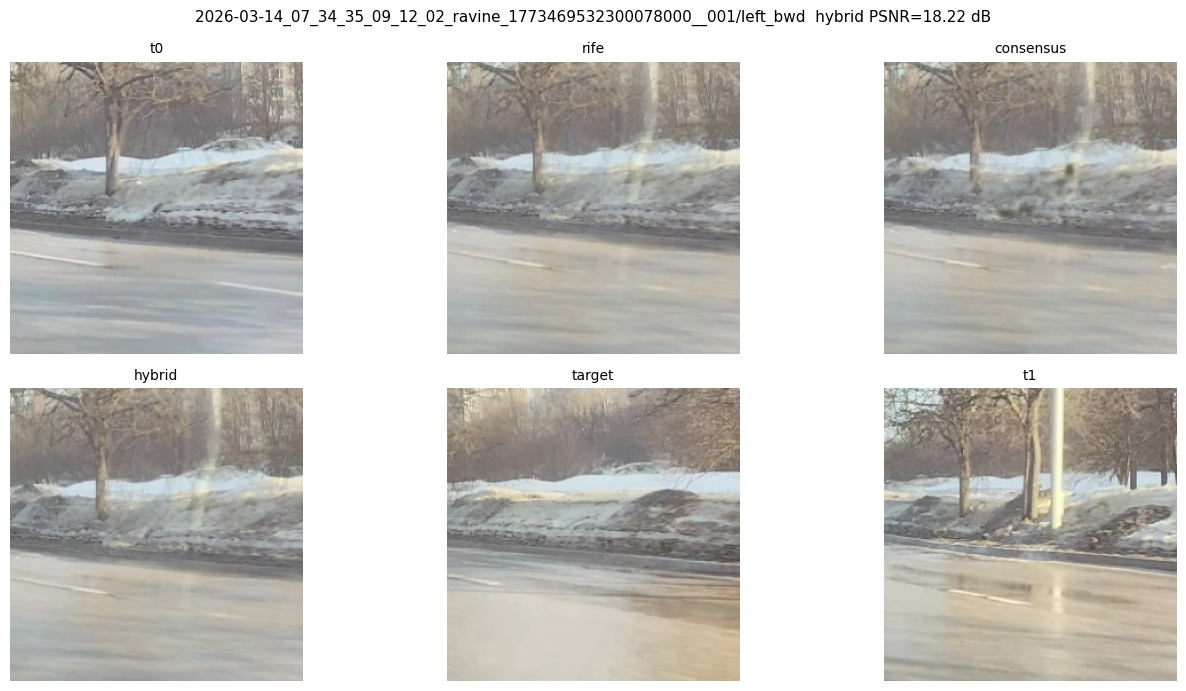


[1] 2026-03-14_18_53_24_19_40_46_mika_1773507185399647000__000  camera=front


    files: OK


  RAM cache: preloading 1 samples...


  RAM cache: done in 0.3s


    PSNR RIFE=24.96  consensus=24.39  hybrid=24.95 dB


...

    PSNR RIFE=20.07  consensus=20.70  hybrid=20.46 dB



=== verify_samples OK ===


  RAM cache: preloading 1 samples...


  RAM cache: done in 0.3s


  x: (27, 256, 256), finite=True
  rife: (3, 256, 256), finite=True
  consensus_tuned: (3, 256, 256), finite=True
  confidence: (256, 256), finite=True
  gt: (3, 256, 256), finite=True


In [3]:
# V2 pipeline (refine_v2.py)
_V2_DIR = Path(r"C:/Users/adel/Documents/GitHub/YA-/Второй этап")
if not (_V2_DIR / "refine_v2.py").is_file():
    _V2_DIR = Path.cwd()
if str(_V2_DIR) not in sys.path:
    sys.path.insert(0, str(_V2_DIR))
from refine_v2 import (
    RefineDataset,
    sample_asset_paths,
    resolve_source_dir,
    hybrid_base_from_batch,
    IN_CHANNELS_V1,
    IN_CHANNELS_V2,
    MAX_WARP_SLOTS,
)


def load_image_uint8(path: str) -> np.ndarray:
    return np.array(Image.open(path).convert("RGB"))


def _ensure_3ch(arr: np.ndarray) -> np.ndarray:
    if arr.ndim == 2:
        return np.stack([arr] * 3, axis=-1)
    return arr


def discover_baked(data_root: str) -> List[Path]:
    root = Path(data_root)
    if not root.is_dir():
        return []
    dirs = []
    for p in sorted(root.iterdir()):
        if not p.is_dir():
            continue
        if all((p / f"d{i}.npy").is_file() for i in (0, 1, 2)) and (p / "meta.json").is_file():
            dirs.append(p)
    return dirs


def prepare_samples(cfg: Config) -> List[Path]:
    baked = discover_baked(cfg.data_root)
    ready = [p for p in baked if sample_asset_paths(
        p, cfg.dataset_root, cfg.consensus_root, cfg.rife_root, cfg.consensus_file)]
    missing = len(baked) - len(ready)
    if missing:
        print(f"  пропущено без RGB/RIFE/warps/consensus: {missing}")
    rng = random.Random(cfg.seed)
    rng.shuffle(ready)
    if cfg.max_samples and cfg.max_samples > 0:
        ready = ready[: cfg.max_samples]
    return ready


def make_refine_dataset(
    sample_dirs: List[Path],
    cfg: Config,
    patch_size=...,
    augment: bool = True,
    fixed_crop: Optional[str] = None,
    cache_full: Optional[bool] = None,
    channel_layout: Optional[str] = None,
) -> RefineDataset:
    ps = cfg.patch_size if patch_size is ... else patch_size
    use_cache = cfg.cache_in_ram if cache_full is None else cache_full
    layout = channel_layout or cfg.channel_layout
    return RefineDataset(
        sample_dirs,
        dataset_root=cfg.dataset_root,
        consensus_root=cfg.consensus_root,
        rife_root=cfg.rife_root,
        consensus_file=cfg.consensus_file,
        channel_layout=layout,
        patch_size=ps,
        augment=augment,
        target_h=cfg.image_h,
        target_w=cfg.image_w,
        fixed_crop=fixed_crop,
        cache_full=use_cache,
    )


def make_dataloader(ds: Dataset, batch_size: int, shuffle: bool, cfg: Config, drop_last: bool = False) -> DataLoader:
    nw = effective_num_workers(cfg)
    return DataLoader(
        ds, batch_size=batch_size, shuffle=shuffle, num_workers=nw,
        pin_memory=(DEVICE.type == "cuda"), drop_last=drop_last,
    )


def _psnr_u8_np(pred: np.ndarray, gt: np.ndarray) -> float:
    if pred.max() > 1.5:
        pred = pred.astype(np.float32) / 255.0
    if gt.max() > 1.5:
        gt = gt.astype(np.float32) / 255.0
    pu = np.clip(pred * 255.0, 0, 255).round()
    gu = np.clip(gt * 255.0, 0, 255).round()
    mse = float(((pu - gu) ** 2).mean())
    if mse < 1e-10:
        return 99.0
    return 20.0 * math.log10(255.0 / math.sqrt(mse))


def _psnr_u8_chw(pred: torch.Tensor, gt: torch.Tensor) -> float:
    """PSNR для [3,H,W] или [1,3,H,W] float [0,1] — до определения psnr_uint8 в §6."""
    if pred.dim() == 4:
        pred = pred[0]
    if gt.dim() == 4:
        gt = gt[0]
    p = pred.detach().cpu().numpy().transpose(1, 2, 0)
    g = gt.detach().cpu().numpy().transpose(1, 2, 0)
    return _psnr_u8_np(p, g)


# alias — §6 переопределит, но verify/sanity работают и без §6
psnr_uint8 = _psnr_u8_chw


def describe_sample_bundle(baked_dir: Path, cfg: Config) -> dict:
    meta = json.loads((baked_dir / "meta.json").read_text(encoding="utf-8"))
    sid, cam = meta["sample_id"], meta["camera"]
    src = resolve_source_dir(meta, Path(cfg.dataset_root))
    paths = {
        "i0": src / "input" / "t0" / f"{cam}.jpg",
        "i2": src / "input" / "t1" / f"{cam}.jpg",
        "gt": src / "target" / f"{cam}.jpg",
        "rife": Path(cfg.rife_root) / f"{sid}.jpg",
        "consensus": Path(cfg.consensus_root) / sid / cfg.consensus_file,
        "confidence": Path(cfg.consensus_root) / sid / "confidence.npy",
        "baked": baked_dir,
    }
    return {"sample_id": sid, "camera": cam, "source_dir": str(src), "paths": paths, "meta": meta}


def verify_samples(cfg: Config, sample_dirs: List[Path], n_check: int = 3, show_plot: bool = True) -> None:
    if not sample_dirs:
        raise RuntimeError("SAMPLES пуст — проверь пути")
    n_check = min(n_check, len(sample_dirs))
    print(f"=== verify_samples: {n_check} комплект(а) ===", flush=True)
    ok_all = True

    for i, baked_dir in enumerate(sample_dirs[:n_check]):
        rec = describe_sample_bundle(baked_dir, cfg)
        sid, cam, paths = rec["sample_id"], rec["camera"], rec["paths"]
        print(f"\n[{i}] {sid}  camera={cam}", flush=True)
        missing = [k for k, p in paths.items() if k != "baked" and not Path(p).is_file()]
        if missing:
            ok_all = False
            print(f"    MISSING: {missing}", flush=True)
            continue
        print("    files: OK", flush=True)

        ds = make_refine_dataset([baked_dir], cfg, patch_size=None, augment=False)
        batch = ds[0]
        assert batch["x"].shape[0] == cfg.in_channels
        psnr_rife = _psnr_u8_chw(batch["rife"], batch["gt"])
        psnr_cons = _psnr_u8_chw(batch["consensus_tuned"], batch["gt"])
        hybrid = hybrid_base_from_batch({k: batch[k].unsqueeze(0) for k in ("rife", "consensus_tuned", "confidence")})
        psnr_hyb = _psnr_u8_chw(hybrid[0], batch["gt"])
        print(f"    PSNR RIFE={psnr_rife:.2f}  consensus={psnr_cons:.2f}  hybrid={psnr_hyb:.2f} dB", flush=True)

        if show_plot and i == 0:
            ph = cfg.patch_size
            y0 = (batch["gt"].shape[1] - ph) // 2
            x0 = (batch["gt"].shape[2] - ph) // 2
            sl = lambda t: t[:, y0:y0+ph, x0:x0+ph]
            tiles = {
                "t0": sl(batch["x"][0:3]),
                "rife": sl(batch["rife"]),
                "consensus": sl(batch["consensus_tuned"]),
                "hybrid": sl(hybrid[0]),
                "target": sl(batch["gt"]),
                "t1": sl(batch["x"][3:6]),
            }
            fig, axes = plt.subplots(2, 3, figsize=(14, 7))
            for ax, (title, img) in zip(axes.flat, tiles.items()):
                ax.imshow((img.clamp(0, 1).cpu().numpy().transpose(1, 2, 0) * 255).astype(np.uint8))
                ax.set_title(title, fontsize=10)
                ax.axis("off")
            fig.suptitle(f"{sid}/{cam}  hybrid PSNR={psnr_hyb:.2f} dB", fontsize=11)
            plt.tight_layout()
            plt.show()

    if not ok_all:
        raise RuntimeError("verify_samples: есть проблемы")
    print("\n=== verify_samples OK ===", flush=True)


SAMPLES = prepare_samples(CFG)
print(f"Запечено: {len(discover_baked(CFG.data_root))}  готово: {len(SAMPLES)}")
if SAMPLES:
    verify_samples(CFG, SAMPLES, n_check=3, show_plot=True)
    ds = make_refine_dataset(SAMPLES[:1], CFG, patch_size=CFG.patch_size, augment=False)
    batch = ds[0]
    for k, v in batch.items():
        print(f"  {k}: {tuple(v.shape)}, finite={torch.isfinite(v).all().item()}")
    assert batch["x"].shape[0] == CFG.in_channels
else:
    print("Нет сэмплов!")


## 3b. Запекание depth (локально, один раз)

```powershell
cd C:\Users\adel\Documents\GitHub\YA-\Второй этап
python bake_refinement_assets.py --workers 8
```

На Colab достаточно залить на Drive готовую папку `rife_refinement_baked/train` (только `.npy` + `meta.json`) + исходный train + multiview_warps.


## 4. Модель: RefineUNetV2 (hybrid base)

- **Вход:** 27 каналов, **выход:** residual + hybrid base
- Zero-init → старт = `conf*consensus + (1-conf)*RIFE`
- `base_channels=32` → ~5M параметров, как раз под маленький датасет




In [4]:
from refine_v2 import RefineUNet, RefineUNetV2, ConvBlock, model_predict, hybrid_base, IN_CHANNELS_V1, IN_CHANNELS_V2


def build_model(cfg: Config) -> nn.Module:
    if cfg.model_version == "v2":
        return RefineUNetV2(cfg.in_channels, cfg.out_channels, cfg.base_channels, use_hybrid_base=cfg.hybrid_base)
    return RefineUNet(cfg.in_channels, cfg.out_channels, cfg.base_channels)


def model_sanity_check(cfg: Config = CFG):
    if cfg.model_version == "v2":
        m = RefineUNetV2(cfg.in_channels, cfg.out_channels, cfg.base_channels, use_hybrid_base=True)
        x = torch.randn(2, IN_CHANNELS_V2, 256, 256)
        rife = torch.rand(2, 3, 256, 256)
        cons = torch.rand(2, 3, 256, 256)
        conf = torch.rand(2, 1, 256, 256)
        out = m(x, rife, cons, conf)
        base_h = hybrid_base(rife, cons, conf)
        diff = (out - base_h.clamp(0, 1)).abs().max().item()
        print(f"RefineUNetV2  params={sum(p.numel() for p in m.parameters())/1e6:.2f}M")
        print(f"  zero-init |out-hybrid|_max = {diff:.6f}  (≈0)")
    else:
        m = RefineUNet(IN_CHANNELS_V1, cfg.out_channels, cfg.base_channels)
        x = torch.randn(2, IN_CHANNELS_V1, 256, 256)
        base = torch.rand(2, 3, 256, 256)
        out = m(x, base)
        diff = (out - base.clamp(0, 1)).abs().max().item()
        print(f"RefineUNet V1  params={sum(p.numel() for p in m.parameters())/1e6:.2f}M")
        print(f"  zero-init |out-base|_max = {diff:.6f}  (≈0)")


model_sanity_check()


RefineUNetV2  params=3.36M
  zero-init |out-hybrid|_max = 0.000000  (≈0)


## 5. EMA (Exponential Moving Average)

Поддерживает медленно обновляющуюся копию весов. Для маленьких датасетов критично — даёт +0.3-0.5 dB бесплатно.


In [5]:
class ModelEMA:
    def __init__(self, model: nn.Module, decay: float = 0.9995):
        self.decay = decay
        self.module = copy.deepcopy(model).eval()
        for p in self.module.parameters():
            p.requires_grad_(False)

    @torch.no_grad()
    def update(self, model: nn.Module):
        d = self.decay
        for ep, p in zip(self.module.parameters(), model.parameters()):
            ep.data.mul_(d).add_(p.data, alpha=1 - d)
        # буферы (BN running stats) — просто копируем
        for eb, b in zip(self.module.buffers(), model.buffers()):
            eb.data.copy_(b.data)


## 6. Метрика PSNR и loss

PSNR считаем **с uint8-квантованием** — именно так его будут считать при оценке.


In [6]:
@torch.no_grad()
def psnr_uint8(pred: torch.Tensor, gt: torch.Tensor) -> float:
    """pred, gt: [B, 3, H, W] float в [0, 1]."""
    pred_u8 = (pred.clamp(0, 1) * 255.0).round()
    gt_u8   = (gt.clamp(0, 1)   * 255.0).round()
    mse = ((pred_u8 - gt_u8) ** 2).mean().item()
    if mse < 1e-10:
        return 99.0
    return 20.0 * math.log10(255.0 / math.sqrt(mse))


@torch.no_grad()
def psnr_float(pred: torch.Tensor, gt: torch.Tensor) -> float:
    """PSNR на float, без квантования — для отслеживания во время тренировки."""
    mse = ((pred - gt) ** 2).mean().item()
    if mse < 1e-10:
        return 99.0
    return 20.0 * math.log10(1.0 / math.sqrt(mse))


def compute_loss(pred: torch.Tensor, gt: torch.Tensor) -> torch.Tensor:
    """MSE — оптимальный loss под PSNR-метрику."""
    return F.mse_loss(pred, gt)


## 7. Train / Val split

Простой стратифицированный split. Для финальных архитектурных решений можно перейти на 5-fold CV — добавлю в отдельной ячейке ниже.


In [7]:
def make_split(all_samples: List[Path], val_fraction: float, seed: int = 42):
    rng = random.Random(seed)
    samples = list(all_samples)
    rng.shuffle(samples)
    n_val = int(round(len(samples) * val_fraction))
    val = samples[:n_val]
    train = samples[n_val:]
    return train, val


def make_kfold(all_samples: List[Path], k: int = 5, seed: int = 42):
    """Возвращает список из k пар (train, val)."""
    rng = random.Random(seed)
    samples = list(all_samples)
    rng.shuffle(samples)
    n = len(samples)
    folds = []
    for i in range(k):
        v_start = i * n // k
        v_end   = (i + 1) * n // k
        val = samples[v_start:v_end]
        train = samples[:v_start] + samples[v_end:]
        folds.append((train, val))
    return folds


# Пример:
# train_dirs, val_dirs = make_split(SAMPLES, CFG.val_fraction, CFG.seed)
# print(f"Train: {len(train_dirs)}, Val: {len(val_dirs)}")


## 8. Training loop

Содержит:
- AMP (bf16) для скорости на 4060 Ti
- Cosine LR с warmup
- Gradient clipping
- EMA-обновление
- Логирование train/val PSNR


In [8]:
def cosine_with_warmup(step: int, total_steps: int, warmup_steps: int,
                       base_lr: float, min_lr: float = 1e-6) -> float:
    if step < warmup_steps:
        return base_lr * (step + 1) / max(1, warmup_steps)
    progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return min_lr + 0.5 * (base_lr - min_lr) * (1 + math.cos(math.pi * progress))


@torch.no_grad()
def evaluate(model: nn.Module, loader: DataLoader, device, cfg: Config,
             use_amp: bool = True, amp_dtype: torch.dtype = torch.bfloat16,
             base_mode: str = "hybrid") -> float:
    model.eval()
    psnrs = []
    for batch in loader:
        batch = {k: v.to(device, non_blocking=True) for k, v in batch.items()}
        with torch.autocast(device_type=device.type, dtype=amp_dtype, enabled=use_amp):
            pred = model_predict(model, batch, base_mode=base_mode).float()
        gt = batch["gt"]
        for i in range(pred.size(0)):
            psnrs.append(psnr_uint8(pred[i:i+1], gt[i:i+1]))
    return float(np.mean(psnrs))


def train_one_run(model: nn.Module, train_loader: DataLoader, val_loader: DataLoader,
                  cfg: Config, tag: str = "run", base_mode: str = "hybrid") -> dict:
    device = DEVICE
    print_cuda_status(tag)
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    amp_dtype = torch.bfloat16 if cfg.amp_dtype == "bf16" else torch.float16
    if device.type == "cuda" and cfg.amp_dtype == "bf16" and not torch.cuda.is_bf16_supported():
        amp_dtype = torch.float16
    scaler = torch.amp.GradScaler(device.type) if (cfg.use_amp and amp_dtype == torch.float16) else None
    ema = ModelEMA(model, decay=cfg.ema_decay) if cfg.use_ema else None

    steps_per_epoch = len(train_loader)
    total_steps = cfg.num_epochs * steps_per_epoch
    warmup_steps = cfg.warmup_epochs * steps_per_epoch
    print(f"[{tag}] epochs={cfg.num_epochs}  steps/epoch={steps_per_epoch}  amp={amp_dtype}", flush=True)

    history = {"train_psnr": [], "val_psnr": [], "val_psnr_ema": [], "lr": []}
    best_psnr = -1.0
    best_ckpt_path = None
    global_step = 0

    for epoch in range(cfg.num_epochs):
        model.train()
        ep_train_psnr = []
        print(f"[{tag}] epoch {epoch+1}/{cfg.num_epochs} — train...", flush=True)
        for batch in train_loader:
            lr = cosine_with_warmup(global_step, total_steps, warmup_steps, cfg.lr)
            for g in optimizer.param_groups:
                g["lr"] = lr
            batch = {k: v.to(device, non_blocking=True) for k, v in batch.items()}
            gt = batch["gt"]
            optimizer.zero_grad(set_to_none=True)
            with torch.autocast(device_type=device.type, dtype=amp_dtype, enabled=cfg.use_amp):
                pred = model_predict(model, batch, base_mode=base_mode)
                loss = compute_loss(pred, gt)
            if scaler is not None:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
                optimizer.step()
            if ema is not None:
                ema.update(model)
            with torch.no_grad():
                ep_train_psnr.append(psnr_float(pred.float(), gt))
            if global_step == 0:
                print(f"[{tag}] first step OK  loss={loss.item():.4f}", flush=True)
            global_step += 1

        print(f"[{tag}] epoch {epoch+1} — val...", flush=True)
        train_psnr = float(np.mean(ep_train_psnr))
        val_psnr = evaluate(model, val_loader, device, cfg, cfg.use_amp, amp_dtype, base_mode)
        val_psnr_ema = evaluate(ema.module, val_loader, device, cfg, cfg.use_amp, amp_dtype, base_mode) if ema else val_psnr
        history["train_psnr"].append(train_psnr)
        history["val_psnr"].append(val_psnr)
        history["val_psnr_ema"].append(val_psnr_ema)
        history["lr"].append(lr)
        score = max(val_psnr, val_psnr_ema)
        marker = ""
        if score > best_psnr:
            best_psnr = score
            ckpt_path = Path(cfg.save_dir) / f"{tag}_best.pt"
            torch.save({"model": model.state_dict(), "ema": ema.module.state_dict() if ema else None,
                        "epoch": epoch, "val_psnr": val_psnr, "config": cfg.__dict__}, ckpt_path)
            best_ckpt_path = ckpt_path
            marker = " *"
        print(f"[{tag}] ep {epoch+1}  lr={lr:.2e}  train={train_psnr:.3f}  val={val_psnr:.3f}  ema={val_psnr_ema:.3f}{marker}", flush=True)

    print(f"\n[{tag}] BEST PSNR: {best_psnr:.3f} dB  ({best_ckpt_path})", flush=True)
    return {"history": history, "best_psnr": best_psnr, "best_ckpt": best_ckpt_path}


## 9. SANITY CHECK — overfit 1 патча

1 сэмпл, center-crop 256×256, 2500 шагов, lr=5e-4.

Цель: **PSNR > 33 dB** и **+12 dB над consensus** (зависит от сэмпла; 33.7 при consensus ~19.3 — OK).



In [9]:
def sanity_overfit_test(steps: int = 2500, lr: float = 5e-4, log_every: int = 500):
    print_cuda_status("sanity")
    assert len(SAMPLES) >= 1
    ds = make_refine_dataset(SAMPLES[:1], CFG, patch_size=CFG.patch_size, augment=False, fixed_crop="center")
    batch = {k: v.unsqueeze(0).to(DEVICE) for k, v in ds[0].items()}

    hybrid = hybrid_base_from_batch(batch)
    psnr_rife = psnr_uint8(batch["rife"], batch["gt"])
    psnr_cons = psnr_uint8(batch["consensus_tuned"], batch["gt"])
    psnr_hyb = psnr_uint8(hybrid, batch["gt"])
    print(f"sanity patch={CFG.patch_size}  RIFE={psnr_rife:.2f}  consensus={psnr_cons:.2f}  hybrid={psnr_hyb:.2f} dB", flush=True)

    model = build_model(CFG).to(DEVICE)
    with torch.no_grad():
        pred0 = model_predict(model, batch).float()
    psnr0 = psnr_uint8(pred0, batch["gt"])
    assert abs(psnr0 - psnr_hyb) < 0.05, f"zero-init ≠ hybrid: {psnr0:.2f} vs {psnr_hyb:.2f}"
    print(f"  identity start OK: pred={psnr0:.2f} dB ≈ hybrid", flush=True)

    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.0)
    amp_dtype = torch.bfloat16 if CFG.amp_dtype == "bf16" else torch.float16
    best_psnr = psnr_hyb
    for step in range(1, steps + 1):
        model.train()
        opt.zero_grad(set_to_none=True)
        with torch.autocast(device_type=DEVICE.type, dtype=amp_dtype, enabled=CFG.use_amp):
            pred = model_predict(model, batch)
            loss = compute_loss(pred, batch["gt"])
        loss.backward()
        opt.step()
        if step % log_every == 0 or step == steps:
            p = psnr_uint8(pred.detach().float(), batch["gt"])
            best_psnr = max(best_psnr, p)
            print(f"  step {step:5d}  loss={loss.item():.5f}  PSNR={p:.2f} dB", flush=True)

    print(f"\n>>> Sanity: best={best_psnr:.2f} dB  (hybrid start={psnr_hyb:.2f})", flush=True)
    assert best_psnr > psnr_hyb + 8.0, f"Слабый overfit: {best_psnr:.1f} vs hybrid {psnr_hyb:.1f}"
    return {"best_psnr": best_psnr, "hybrid_psnr": psnr_hyb, "rife_psnr": psnr_rife}


## 10. Baseline обучение

**Sanity** — center-патч 256 (только проверка overfit).  
**Baseline** — train **random patch 256×256**, val **full frame 1024×544**, данные в **RAM cache** (без повторного чтения jpg с диска).

Ожидание: val PSNR чуть выше consensus (+0.5…2 dB), не overfit 40 dB.



In [20]:
def measure_baselines(val_loader: DataLoader, device) -> dict:
    """RIFE / consensus / hybrid — без обучения."""
    rife_ps, cons_ps, hyb_ps = [], [], []
    for batch in val_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        gt = batch["gt"]
        hybrid = hybrid_base_from_batch(batch)
        for i in range(gt.size(0)):
            rife_ps.append(psnr_uint8(batch["rife"][i:i+1], gt[i:i+1]))
            cons_ps.append(psnr_uint8(batch["consensus_tuned"][i:i+1], gt[i:i+1]))
            hyb_ps.append(psnr_uint8(hybrid[i:i+1], gt[i:i+1]))
    return {
        "rife": float(np.mean(rife_ps)),
        "consensus": float(np.mean(cons_ps)),
        "hybrid": float(np.mean(hyb_ps)),
    }


def run_baseline_training(cfg: Config = CFG, tag: str = "v2_hybrid"):
    assert len(SAMPLES) >= 8
    train_dirs, val_dirs = make_split(SAMPLES, cfg.val_fraction, cfg.seed)
    train_ps = None if cfg.train_full_frame else cfg.patch_size
    print(f"Train: {len(train_dirs)}, Val: {len(val_dirs)}")
    train_ds = make_refine_dataset(train_dirs, cfg, patch_size=train_ps, augment=True, cache_full=True)
    val_ds = make_refine_dataset(val_dirs, cfg, patch_size=None, augment=False, cache_full=True)
    train_loader = make_dataloader(train_ds, cfg.batch_size, True, cfg, drop_last=True)
    val_loader = make_dataloader(val_ds, 1, False, cfg)

    baselines = measure_baselines(val_loader, DEVICE)
    print(f"\n>>> Baselines (val): RIFE={baselines['rife']:.3f}  consensus={baselines['consensus']:.3f}  hybrid={baselines['hybrid']:.3f} dB", flush=True)

    model = build_model(cfg)
    result = train_one_run(model, train_loader, val_loader, cfg, tag=tag)
    delta = result["best_psnr"] - baselines["hybrid"]
    print(f"\n>>> Refinement vs hybrid: {delta:+.3f} dB ({baselines['hybrid']:.3f} → {result['best_psnr']:.3f})")
    return result, baselines, val_loader


# Раскомментируй для прогона:
baseline_result, baselines, val_loader = run_baseline_training()


Train: 168, Val: 32
  RAM cache: preloading 168 samples...


  RAM cache: done in 48.8s


  RAM cache: preloading 32 samples...


  RAM cache: done in 11.7s



>>> Baselines (val): RIFE=19.809  consensus=19.438  hybrid=20.125 dB


...

[v2_hybrid] epoch 80/80 — train...


[v2_hybrid] epoch 80 — val...


[v2_hybrid] ep 80  lr=1.00e-06  train=19.290  val=20.028  ema=20.137



[v2_hybrid] BEST PSNR: 20.150 dB  (checkpoints\v2_hybrid_best.pt)



>>> Refinement vs hybrid: +0.025 dB (20.125 → 20.150)


## 10b. Quick start

1. **Dataset** — verify + RAM cache (~30–60 с на 100 сэмплов)
2. **Sanity** — overfit 1 center-патча (~2 мин) — только проверка pipeline
3. **Baseline** — отдельная ячейка §10, full frame, ~3–5 мин/эпоха после cache

In [11]:
# Sanity only (baseline — отдельно в §10, не здесь)
print_cuda_status("quick_start")
verify_samples(CFG, SAMPLES, n_check=min(3, len(SAMPLES)), show_plot=False)
sanity_result = sanity_overfit_test(steps=2500)
print("\nSanity OK. Baseline: run_baseline_training() в ячейке §10", flush=True)

[quick_start] DEVICE=cuda  cuda_available=True


[quick_start] GPU=NVIDIA GeForce RTX 4060 Ti


[quick_start] VRAM allocated=0 MB


=== verify_samples: 3 комплект(а) ===



[0] 2026-03-14_07_34_35_09_12_02_ravine_1773469532300078000__001  camera=left_bwd


...

  step  1500  loss=0.00043  PSNR=33.63 dB


  step  2000  loss=0.00029  PSNR=35.38 dB


  step  2500  loss=0.00023  PSNR=36.41 dB



>>> Sanity: best=36.41 dB  (hybrid start=19.31)



Sanity OK. Baseline: run_baseline_training() в ячейке §10


## 11. TTA inference (8× геометрических аугментаций)

Усреднение по 8 вариантам (4 поворота × 2 флипа). Почти бесплатные +0.1–0.3 dB.


In [12]:
@torch.no_grad()
def tta_predict(model: nn.Module, batch: dict, cfg: Config = CFG,
                use_amp: bool = True, amp_dtype: torch.dtype = torch.bfloat16,
                base_mode: str = "hybrid") -> torch.Tensor:
    model.eval()
    device = batch["x"].device
    preds = []

    def fwd(b):
        with torch.autocast(device_type=device.type, dtype=amp_dtype, enabled=use_amp):
            return model_predict(model, b, base_mode=base_mode).float()

    x, rife = batch["x"], batch["rife"]
    cons, conf, gt = batch["consensus_tuned"], batch["confidence"], batch["gt"]
    for k in range(4):
        for flip in (False, True):
            def aug(t):
                t = torch.rot90(t, k=k, dims=(-2, -1))
                return torch.flip(t, (-1,)) if flip else t
            b = {"x": aug(x), "rife": aug(rife), "consensus_tuned": aug(cons),
                 "confidence": aug(conf), "gt": aug(gt)}
            p = fwd(b)
            if flip:
                p = torch.flip(p, (-1,))
            p = torch.rot90(p, k=-k, dims=(-2, -1))
            preds.append(p)
    return torch.stack(preds, dim=0).mean(dim=0)


@torch.no_grad()
def evaluate_with_tta(model: nn.Module, loader: DataLoader, device, cfg: Config = CFG,
                      base_mode: str = "hybrid") -> float:
    model.eval()
    psnrs = []
    amp_dtype = torch.bfloat16 if cfg.amp_dtype == "bf16" else torch.float16
    for batch in loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        pred = tta_predict(model, batch, cfg, base_mode=base_mode)
        gt = batch["gt"]
        for i in range(pred.size(0)):
            psnrs.append(psnr_uint8(pred[i:i+1], gt[i:i+1]))
    return float(np.mean(psnrs))


## 12. Визуализация

Покажем: I_0, consensus, наше предсказание, GT, и карту ошибок.



In [13]:
def to_numpy_img(t: torch.Tensor) -> np.ndarray:
    return (t.clamp(0, 1).cpu().numpy().transpose(1, 2, 0) * 255).astype(np.uint8)


@torch.no_grad()
def visualize_one(model: nn.Module, dataset: Dataset, idx: int = 0, cfg: Config = CFG, use_tta: bool = True):
    model.eval()
    batch_cpu = dataset[idx]
    batch = {k: v.unsqueeze(0).to(DEVICE) for k, v in batch_cpu.items()}
    hybrid = hybrid_base_from_batch(batch)
    if use_tta:
        pred = tta_predict(model, batch, cfg)
    else:
        pred = model_predict(model, batch).float()

    gt = batch["gt"]
    psnr_rife = psnr_uint8(batch["rife"], gt)
    psnr_hyb = psnr_uint8(hybrid, gt)
    psnr_pred = psnr_uint8(pred, gt)
    I0 = batch_cpu["x"][0:3]
    I2 = batch_cpu["x"][3:6]

    fig, axes = plt.subplots(2, 4, figsize=(16, 7))
    axes[0,0].imshow(to_numpy_img(I0)); axes[0,0].set_title("I_0")
    axes[0,1].imshow(to_numpy_img(batch["rife"][0])); axes[0,1].set_title(f"RIFE ({psnr_rife:.2f})")
    axes[0,2].imshow(to_numpy_img(hybrid[0])); axes[0,2].set_title(f"hybrid ({psnr_hyb:.2f})")
    axes[0,3].imshow(to_numpy_img(I2)); axes[0,3].set_title("I_2")
    axes[1,0].imshow(to_numpy_img(gt[0])); axes[1,0].set_title("GT")
    axes[1,1].imshow(to_numpy_img(pred[0])); axes[1,1].set_title(f"Refined ({psnr_pred:.2f})")
    conf = batch["confidence"][0].cpu().numpy()
    axes[1,2].imshow(conf, cmap="viridis", vmin=0, vmax=1); axes[1,2].set_title("confidence")
    err = (pred - gt).abs().mean(dim=1)[0].cpu().numpy()
    axes[1,3].imshow(err, cmap="hot"); axes[1,3].set_title("|pred-GT|")
    for ax in axes.flat:
        ax.axis("off")
    plt.tight_layout()
    plt.show()


## 13. Альтернативная архитектура: MARNet (Modality-Aware Refinement)

Drop-in для **V1 (12ch)**: `x = [I₀, RIFE, I₂, D₀..D₂]`, `forward(x, base=RIFE)`. Требует §4 (`ConvBlock`) или ячейку SPADE ниже.

**Ключевые отличия от baseline:**

1. **Раздельные энкодеры для RGB и depth** с shared весами по времени.
   Один RGB-энкодер применяется к `I_0`, `I_consensus`, `I_2` (3 раза с одними весами).
   Один depth-энкодер применяется к `D_0`, `D_1`, `D_2`.

2. **SPADE-блоки** — depth модулирует RGB через spatial gamma/beta.
   `f_out = γ(D) * normalize(f_rgb) + β(D)` в каждой точке.
   γ и β инициализированы нулями → старт = просто normalize(RGB), без модуляции.

3. **Temporal embedding** — learnable вектор для каждого из 3 временных слотов.

4. **Temporal fusion** — 3 кадра конкатенируются по каналам, conv смешивает на каждом масштабе.

5. **Residual prediction** с zero-init последнего conv — как в baseline.

**Параметры:** ~4–5M (сопоставимо с baseline). Compute ~2× больше из-за тройного прохода через энкодеры.



In [14]:
from refine_v2 import ConvBlock  # FrameEncoder + MARNet decoder

class SPADE(nn.Module):
    """Spatially-Adaptive (DE)normalization.
    Берёт depth-фичи, предсказывает per-pixel γ и β для модуляции RGB-фич.
    Zero-init для γ и β → старт = просто GroupNorm(rgb), без модуляции.
    """
    def __init__(self, rgb_ch: int, depth_ch: int, mid_ch: int = None):
        super().__init__()
        mid_ch = mid_ch or max(rgb_ch // 2, 16)
        self.norm = nn.GroupNorm(num_groups=min(8, rgb_ch), num_channels=rgb_ch, affine=False)
        self.shared = nn.Sequential(
            nn.Conv2d(depth_ch, mid_ch, 3, padding=1),
            nn.ReLU(inplace=True),
        )
        self.to_gamma = nn.Conv2d(mid_ch, rgb_ch, 3, padding=1)
        self.to_beta  = nn.Conv2d(mid_ch, rgb_ch, 3, padding=1)
        nn.init.zeros_(self.to_gamma.weight); nn.init.zeros_(self.to_gamma.bias)
        nn.init.zeros_(self.to_beta.weight);  nn.init.zeros_(self.to_beta.bias)

    def forward(self, rgb_feat: torch.Tensor, depth_feat: torch.Tensor) -> torch.Tensor:
        if depth_feat.shape[-2:] != rgb_feat.shape[-2:]:
            depth_feat = F.interpolate(depth_feat, size=rgb_feat.shape[-2:],
                                       mode="bilinear", align_corners=False)
        normalized = self.norm(rgb_feat)
        h = self.shared(depth_feat)
        gamma = self.to_gamma(h)
        beta  = self.to_beta(h)
        return normalized * (1.0 + gamma) + beta


In [15]:
class FrameEncoder(nn.Module):
    """4-уровневый энкодер для одного кадра (RGB или depth).
    Возвращает features на 4 масштабах: [H, H/2, H/4, H/8].
    """
    def __init__(self, in_ch: int, base: int):
        super().__init__()
        self.b0 = ConvBlock(in_ch, base)
        self.b1 = ConvBlock(base, base * 2)
        self.b2 = ConvBlock(base * 2, base * 4)
        self.b3 = ConvBlock(base * 4, base * 8)
        self.pool = nn.MaxPool2d(2)

    def forward(self, x: torch.Tensor):
        f0 = self.b0(x)
        f1 = self.b1(self.pool(f0))
        f2 = self.b2(self.pool(f1))
        f3 = self.b3(self.pool(f2))
        return [f0, f1, f2, f3]


In [16]:
class MARNet(nn.Module):
    """Modality-Aware Refinement Network.

    Архитектура:
      1. RGB-энкодер (shared) → I_0, RIFE, I_2  (V1 layout, 12ch)
      2. Depth-энкодер (shared) → D_0, D_1, D_2
      3. SPADE на каждом масштабе
      4. Temporal embedding на самом глубоком уровне
      5. Temporal fusion + U-Net декодер, residual output
    """
    def __init__(self, base: int = 32, depth_base: int = 16):
        super().__init__()
        self.rgb_ch   = [base, base * 2, base * 4, base * 8]
        self.depth_ch = [depth_base, depth_base * 2, depth_base * 4, depth_base * 8]

        self.rgb_enc   = FrameEncoder(in_ch=3, base=base)
        self.depth_enc = FrameEncoder(in_ch=1, base=depth_base)

        self.spades = nn.ModuleList([
            SPADE(self.rgb_ch[s], self.depth_ch[s])
            for s in range(4)
        ])

        deepest = self.rgb_ch[3]
        self.temporal_embed = nn.Parameter(torch.zeros(3, deepest))
        nn.init.normal_(self.temporal_embed, std=0.02)

        self.temp_fuse = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(3 * self.rgb_ch[s], self.rgb_ch[s], 3, padding=1),
                nn.GELU(),
                nn.Conv2d(self.rgb_ch[s], self.rgb_ch[s], 3, padding=1),
                nn.GELU(),
            )
            for s in range(4)
        ])

        self.up = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.dec3 = ConvBlock(self.rgb_ch[3] + self.rgb_ch[2], self.rgb_ch[2])
        self.dec2 = ConvBlock(self.rgb_ch[2] + self.rgb_ch[1], self.rgb_ch[1])
        self.dec1 = ConvBlock(self.rgb_ch[1] + self.rgb_ch[0], self.rgb_ch[0])

        self.out = nn.Conv2d(self.rgb_ch[0], 3, 3, padding=1)
        nn.init.zeros_(self.out.weight)
        nn.init.zeros_(self.out.bias)

    def _split_input(self, x: torch.Tensor):
        I0 = x[:, 0:3]
        Ir = x[:, 3:6]
        I2 = x[:, 6:9]
        D0 = x[:, 9:10]
        D1 = x[:, 10:11]
        D2 = x[:, 11:12]
        return [I0, Ir, I2], [D0, D1, D2]

    def forward(self, x: torch.Tensor, base_img: torch.Tensor) -> torch.Tensor:
        rgbs, depths = self._split_input(x)

        rgb_feats   = [self.rgb_enc(I)   for I in rgbs]
        depth_feats = [self.depth_enc(D) for D in depths]

        fused = [[None] * 3 for _ in range(4)]
        for s in range(4):
            for t in range(3):
                fused[s][t] = self.spades[s](rgb_feats[t][s], depth_feats[t][s])

        for t in range(3):
            emb = self.temporal_embed[t].view(1, -1, 1, 1)
            fused[3][t] = fused[3][t] + emb

        merged = []
        for s in range(4):
            cat = torch.cat(fused[s], dim=1)
            merged.append(self.temp_fuse[s](cat))

        d3 = merged[3]
        d2 = self.dec3(torch.cat([self.up(d3), merged[2]], dim=1))
        d1 = self.dec2(torch.cat([self.up(d2), merged[1]], dim=1))
        d0 = self.dec1(torch.cat([self.up(d1), merged[0]], dim=1))

        residual = self.out(d0)
        return (base_img + residual).clamp(0, 1)


def marnet_sanity_check():
    m = MARNet(base=CFG.base_channels, depth_base=CFG.base_channels // 2)
    x = torch.randn(2, 12, 256, 256)
    base = torch.rand(2, 3, 256, 256)
    out = m(x, base)
    n_params = sum(p.numel() for p in m.parameters())
    print(f"MARNet параметров: {n_params/1e6:.2f}M")
    print(f"Вход:  x={tuple(x.shape)}, base={tuple(base.shape)}")
    print(f"Выход: {tuple(out.shape)}, range=[{out.min():.3f}, {out.max():.3f}]")
    diff = (out - base.clamp(0, 1)).abs().max().item()
    print(f"|out - base|_max при zero-init: {diff:.6f}  (должно быть ~0)")

marnet_sanity_check()


MARNet параметров: 6.36M
Вход:  x=(2, 12, 256, 256), base=(2, 3, 256, 256)
Выход: (2, 3, 256, 256), range=[0.000, 1.000]
|out - base|_max при zero-init: 0.000000  (должно быть ~0)


### Обучение MARNet

- **`run_marnet_training()`** — один прогон MARNet (аналог §10 baseline).
- **`run_architecture_comparison()`** — U-Net и MARNet на одном split с одинаковыми гиперпараметрами.


In [19]:
def _make_train_val_loaders(cfg: Config, channel_layout: str | None = None):
    """Общий train/val loader. MARNet требует channel_layout='v1' (12ch)."""
    layout = channel_layout or cfg.channel_layout
    train_dirs, val_dirs = make_split(SAMPLES, cfg.val_fraction, cfg.seed)
    train_ps = None if cfg.train_full_frame else cfg.patch_size
    mode = f"full {cfg.image_w}×{cfg.image_h}" if train_ps is None else f"random patch {train_ps}"
    print(f"Train: {len(train_dirs)}, Val: {len(val_dirs)} (из {len(SAMPLES)})")
    print(f"  layout={layout}  TRAIN: {mode}  |  VAL: full {cfg.image_w}×{cfg.image_h}", flush=True)

    train_ds = make_refine_dataset(train_dirs, cfg, patch_size=train_ps, augment=True,
                                   cache_full=True, channel_layout=layout)
    val_ds = make_refine_dataset(val_dirs, cfg, patch_size=None, augment=False,
                                 cache_full=True, channel_layout=layout)
    train_loader = make_dataloader(train_ds, cfg.batch_size, shuffle=True, cfg=cfg, drop_last=True)
    val_loader = make_dataloader(val_ds, batch_size=1, shuffle=False, cfg=cfg)
    return train_loader, val_loader


def run_marnet_training(num_epochs: int | None = None, tag: str = "marnet32_v1"):
    """MARNet — только V1 layout: x[12] = I₀, RIFE, I₂, D₀..D₂; base=RIFE."""
    assert len(SAMPLES) >= 8, f"Слишком мало сэмплов: {len(SAMPLES)}"
    cfg = replace(CFG, num_epochs=num_epochs) if num_epochs is not None else CFG
    cfg_v1 = replace(cfg, channel_layout="v1", in_channels=12, model_version="v1")
    train_loader, val_loader = _make_train_val_loaders(cfg_v1, channel_layout="v1")

    baselines = measure_baselines(val_loader, DEVICE)
    print(f"\n>>> Baselines (val): RIFE={baselines['rife']:.3f} dB", flush=True)

    model = MARNet(base=cfg_v1.base_channels, depth_base=cfg_v1.base_channels // 2)
    result = train_one_run(model, train_loader, val_loader, cfg_v1, tag=tag, base_mode="rife")

    delta = result["best_psnr"] - baselines["rife"]
    print(f"\n>>> MARNet vs RIFE: {delta:+.3f} dB ({baselines['rife']:.3f} → {result['best_psnr']:.3f})")
    return result, baselines, val_loader


def run_architecture_comparison(num_epochs: int | None = None, tag_suffix: str = ""):
    """RefineUNet V1 vs MARNet на 12ch / RIFE base."""
    assert len(SAMPLES) >= 8, f"Слишком мало сэмплов: {len(SAMPLES)}"
    cfg = replace(CFG, num_epochs=num_epochs) if num_epochs is not None else CFG
    cfg_v1 = replace(cfg, channel_layout="v1", in_channels=12, model_version="v1")
    train_loader, val_loader = _make_train_val_loaders(cfg_v1, channel_layout="v1")

    baselines = measure_baselines(val_loader, DEVICE)
    print(f"\nRIFE val PSNR: {baselines['rife']:.3f} dB\n", flush=True)

    results = {}
    print("=" * 60); print("BASELINE: RefineUNet V1"); print("=" * 60)
    torch.manual_seed(cfg_v1.seed)
    m1 = RefineUNet(cfg_v1.in_channels, cfg_v1.out_channels, cfg_v1.base_channels)
    results["unet"] = train_one_run(m1, train_loader, val_loader, cfg_v1,
                                     tag=f"unet32{tag_suffix}", base_mode="rife")

    print("\n" + "=" * 60); print("MARNet"); print("=" * 60)
    torch.manual_seed(cfg_v1.seed)
    m2 = MARNet(base=cfg_v1.base_channels, depth_base=cfg_v1.base_channels // 2)
    results["marnet"] = train_one_run(m2, train_loader, val_loader, cfg_v1,
                                       tag=f"marnet{tag_suffix}", base_mode="rife")

    print("\n" + "=" * 60); print("СВОДКА"); print("=" * 60)
    print(f"RIFE baseline:    {baselines['rife']:.3f} dB")
    print(f"RefineUNet best:  {results['unet']['best_psnr']:.3f} dB  "
          f"(Δ = {results['unet']['best_psnr'] - baselines['rife']:+.3f})")
    print(f"MARNet best:      {results['marnet']['best_psnr']:.3f} dB  "
          f"(Δ = {results['marnet']['best_psnr'] - baselines['rife']:+.3f})")
    return results, baselines, val_loader


# Один прогон MARNet:
marnet_result, base_psnr, val_loader = run_marnet_training()  # V1 layout only

# Сравнение U-Net vs MARNet (долго — два полных прогона):
# comparison_results, base_baseline, val_loader = run_architecture_comparison()



Train: 168, Val: 32 (из 200)
  layout=v1  TRAIN: random patch 256  |  VAL: full 1024×544


  RAM cache: preloading 168 samples...


  RAM cache: done in 61.8s


  RAM cache: preloading 32 samples...


  RAM cache: done in 13.8s


...

[marnet32_v1] epoch 80/80 — train...


[marnet32_v1] epoch 80 — val...


[marnet32_v1] ep 80  lr=1.00e-06  train=19.929  val=20.499  ema=19.981



[marnet32_v1] BEST PSNR: 20.523 dB  (checkpoints\marnet32_v1_best.pt)



>>> MARNet vs RIFE: +0.714 dB (19.809 → 20.523)


### Полезные ablation-эксперименты

| Версия | Что отключено | Что проверяет |
|---|---|---|
| MARNet full | — | базовый прирост |
| Без SPADE | конкат depth+rgb перед temp_fuse | помогает ли модуляция depth |
| Без temporal embedding | `temporal_embed = 0` | нужен ли явный временной сигнал |
| Без shared weights | 3 отдельных RGB-энкодера | помогает ли shared weights |
| RGB-only (без depth) | depth-каналы = 0 | даёт ли depth сигнал вообще |

RGB-only тест — занулить depth перед forward:

```python
def zero_depth(x):
    x = x.clone()
    x[:, 9:12] = 0
    return x
```


## 14. Дальнейшие улучшения (когда baseline заработает)

В порядке приоритета — внедряй по одному и замеряй прирост PSNR:

1. **EMA + TTA** — уже встроены в этот ноутбук.
2. **Ensemble из 3-5 моделей** с разными seed и/или fold'ами — усредняй предсказания.
3. **5-fold CV** для надёжного сравнения архитектур (используй `make_kfold`).
4. **NAFNet-блоки** вместо простого ConvBlock — SOTA в restoration, обычно +0.3–0.7 dB.
5. **Depth-aware warping**: варпни `I_0` и `I_2` в момент t=1 по depth и добавь как ещё каналы (+6 каналов). Сильная геометрическая подсказка.
6. **Multi-scale loss** — MSE на нескольких уровнях декодера, помогает с границами.
7. **Pretraining на Vimeo90K** (если разрешат внешние данные) — +1–3 dB на маленьком датасете.

### Про consensus как базу

Текущий pipeline ровно это и делает — `I_consensus` лежит в каналах 3–5 входа, и residual прибавляется именно к нему. То есть сеть учится только **уточнять** consensus_tuned, не переделывать его. Это правильный подход для маленького датасета: ты переиспользуешь силу уже обученной модели и не тратишь capacity на воспроизведение того, что consensus уже даёт.

Альтернатива (предсказывать кадр с нуля, игнорируя consensus) — почти наверняка хуже на 1278 сэмплах. consensus уже агрегирует warps; RIFE внутри tuned тысяч триплетов, ты такое количество данных перекрыть не сможешь.

### Замечание про разрешение 1024×544 и patch_size

С patch=256 ты получаешь ~8 непересекающихся патчей с одной картинки. Если хочешь больше variability — уменьши patch до 192 (даст ~15 патчей) или просто увеличь число эпох. На полном изображении 1024×544 валидация уже работает (используется в `val_ds` с `patch_size=None`).




## 14. Ablation A / B / C

| Модель | Каналы | Base | |
|---|---|---|---|
| A (full) | 27 | hybrid | максимум |
| B | 27 | RIFE only | вклад hybrid |
| C | 12 | RIFE only | baseline V1 |


In [18]:
def run_ablation_abc(cfg: Config = CFG, max_epochs: Optional[int] = None):
    """Три прогона с одинаковым split. max_epochs — для быстрого теста."""
    base_cfg = replace(cfg, num_epochs=max_epochs or cfg.num_epochs)
    train_dirs, val_dirs = make_split(SAMPLES, base_cfg.val_fraction, base_cfg.seed)
    train_ps = None if base_cfg.train_full_frame else base_cfg.patch_size
    val_loader = make_dataloader(
        make_refine_dataset(val_dirs, base_cfg, patch_size=None, augment=False, cache_full=True),
        1, False, base_cfg,
    )
    baselines = measure_baselines(val_loader, DEVICE)
    print("Baselines:", baselines)

    specs = [
        ("A_v2_hybrid", replace(base_cfg, model_version="v2", channel_layout="v2", in_channels=27, hybrid_base=True)),
        ("B_v2_rife", replace(base_cfg, model_version="v2", channel_layout="v2", in_channels=27, hybrid_base=False)),
        ("C_v1_rife", replace(base_cfg, model_version="v1", channel_layout="v1", in_channels=12, hybrid_base=False)),
    ]
    results = {}
    for tag, c in specs:
        print(f"\n=== {tag} ===", flush=True)
        tr_ds = make_refine_dataset(train_dirs, c, patch_size=train_ps, augment=True, cache_full=True,
                                    channel_layout=c.channel_layout)
        tr_ld = make_dataloader(tr_ds, c.batch_size, True, c, drop_last=True)
        model = build_model(c)
        base_mode = "rife" if not c.hybrid_base else "hybrid"
        res = train_one_run(model, tr_ld, val_loader, c, tag=tag, base_mode=base_mode)
        results[tag] = res["best_psnr"]
    print("\n=== Ablation summary ===")
    for k, v in results.items():
        print(f"  {k}: {v:.3f} dB  (Δ hybrid={v - baselines['hybrid']:+.3f})")
    return results, baselines

# run_ablation_abc(max_epochs=5)  # быстрый smoke

